# CIC-IoT2023 — Profesyonel EDA

Master sample: `data/eda_samples/iot_master.parquet` (309 dosyadan sinif basina capped stratified orneklem).

Once: `python scripts/build_eda_master_samples.py --domain iot`



CIC-IoT2023 Profesyonel EDA (Master Sample)
Satir: 349,970 | Sinif: 309 | Dosya: 309



1) Veri Kalitesi
Boyut: (349970, 41)
Duplicate satir: 2650

2) Sinif Dengesi (33 sinif — capped stratified sample)
                    count  share_pct  imbalance_ratio_to_max
label                                                       
Mirai-greip_flood5   1146      0.327                    1.00
DDoS-ICMP_Flood      1146      0.327                    1.00
VulnerabilityScan    1146      0.327                    1.00
Recon-PortScan       1146      0.327                    1.00
BenignTraffic        1146      0.327                    1.00
...                   ...        ...                     ...
SqlInjection          751      0.215                    1.53
XSS                   550      0.157                    2.08
Backdoor_Malware      461      0.132                    2.49
Recon-PingSweep       324      0.093                    3.54
Uploading_Attack      179      0.051                    6.40

[309 rows x 3 columns]

Not: IoT dogal olarak cok dengesiz; EDA'da capped sampling kullani

C:\Users\iakta\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)



4) Sabit / Dusuk Varyansli Ozellikler
Sabit: 0 | Dusuk varyans: 0



5) Yuksek Korelasyonlu Ciftler
   feature_a  feature_b  correlation
0   Tot size        AVG       1.0000
1  rst_count  fin_count       0.9697



6) Outlier & MI
Min                0.211755
Variance           0.207824
ack_flag_number    0.207538
ack_count          0.203740
Std                0.186985
Max                0.185682
Protocol Type      0.165537
IAT                0.123693
Rate               0.026674
Tot size           0.005909
AVG                0.005909
Tot sum            0.000311
dtype: float64
Number             0.128113
Time_To_Live       0.071431
IPv                0.066931
LLC                0.066865
Header_Length      0.054466
TCP                0.045158
Tot sum            0.042391
ack_count          0.037376
Tot size           0.037327
AVG                0.037310
HTTPS              0.036960
ack_flag_number    0.033973
Min                0.032823
Max                0.031121
Std                0.027465
Variance           0.027319
IAT                0.026988
Protocol Type      0.026554
psh_flag_number    0.025392
Rate               0.025244
dtype: float64


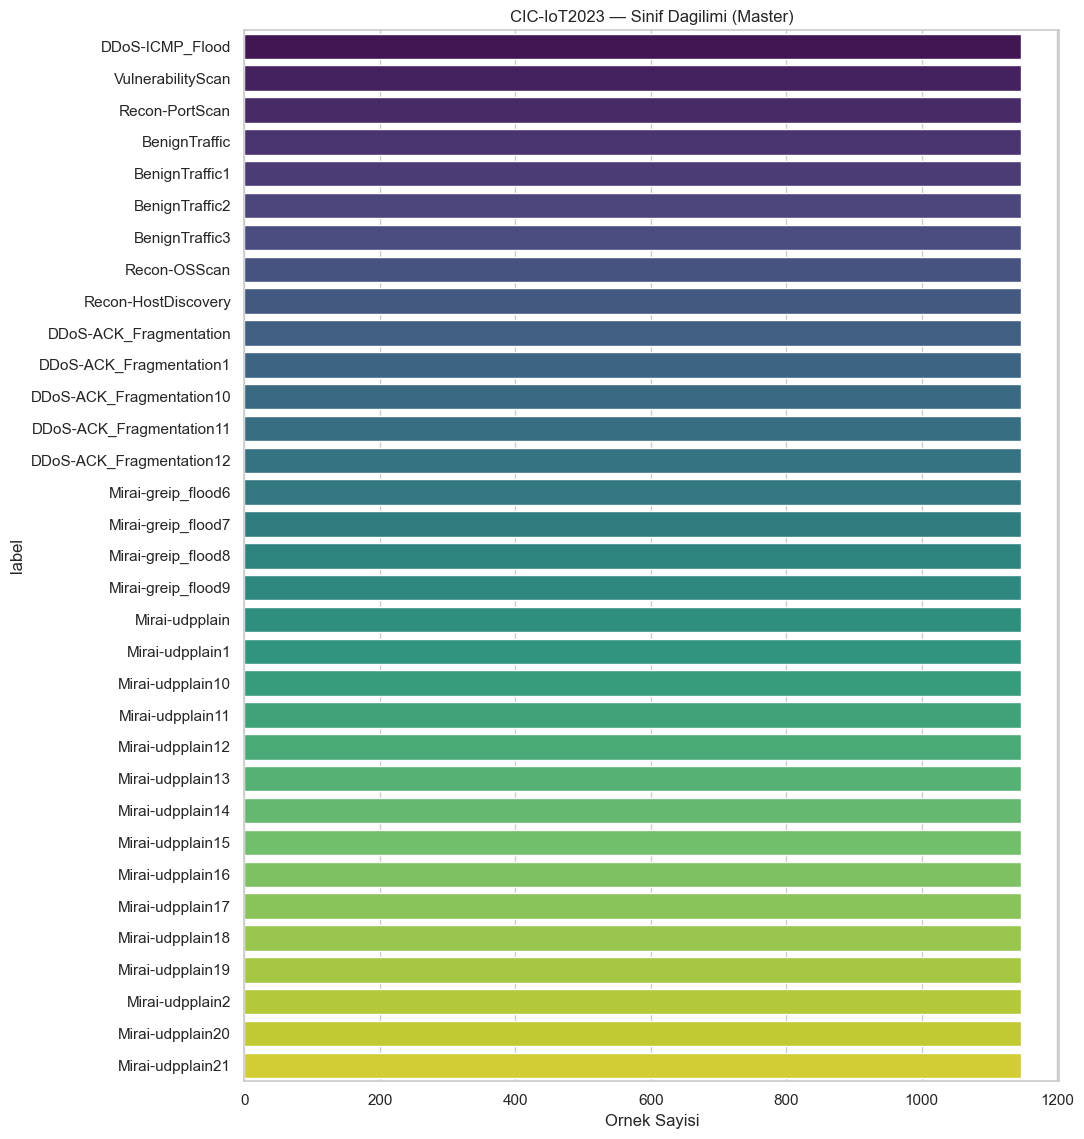

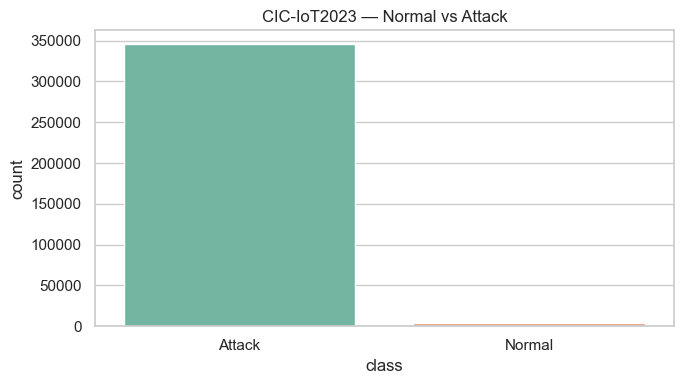

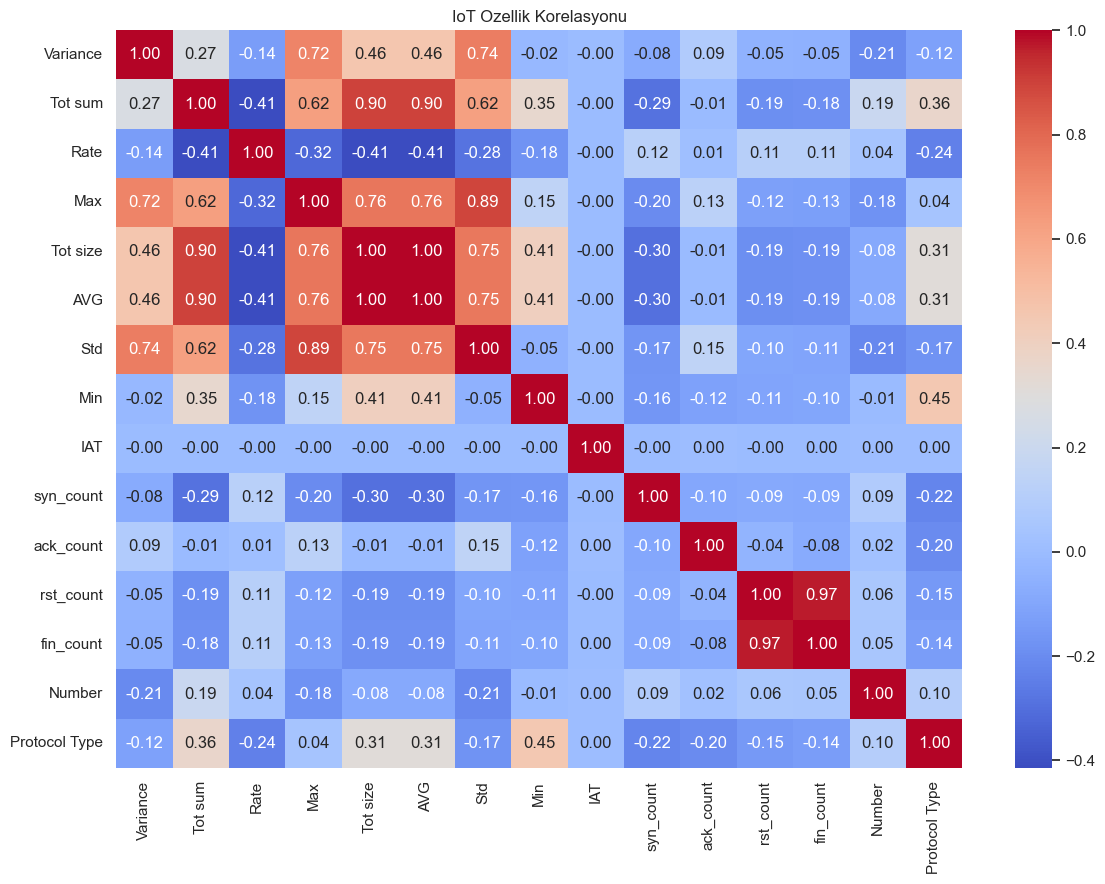

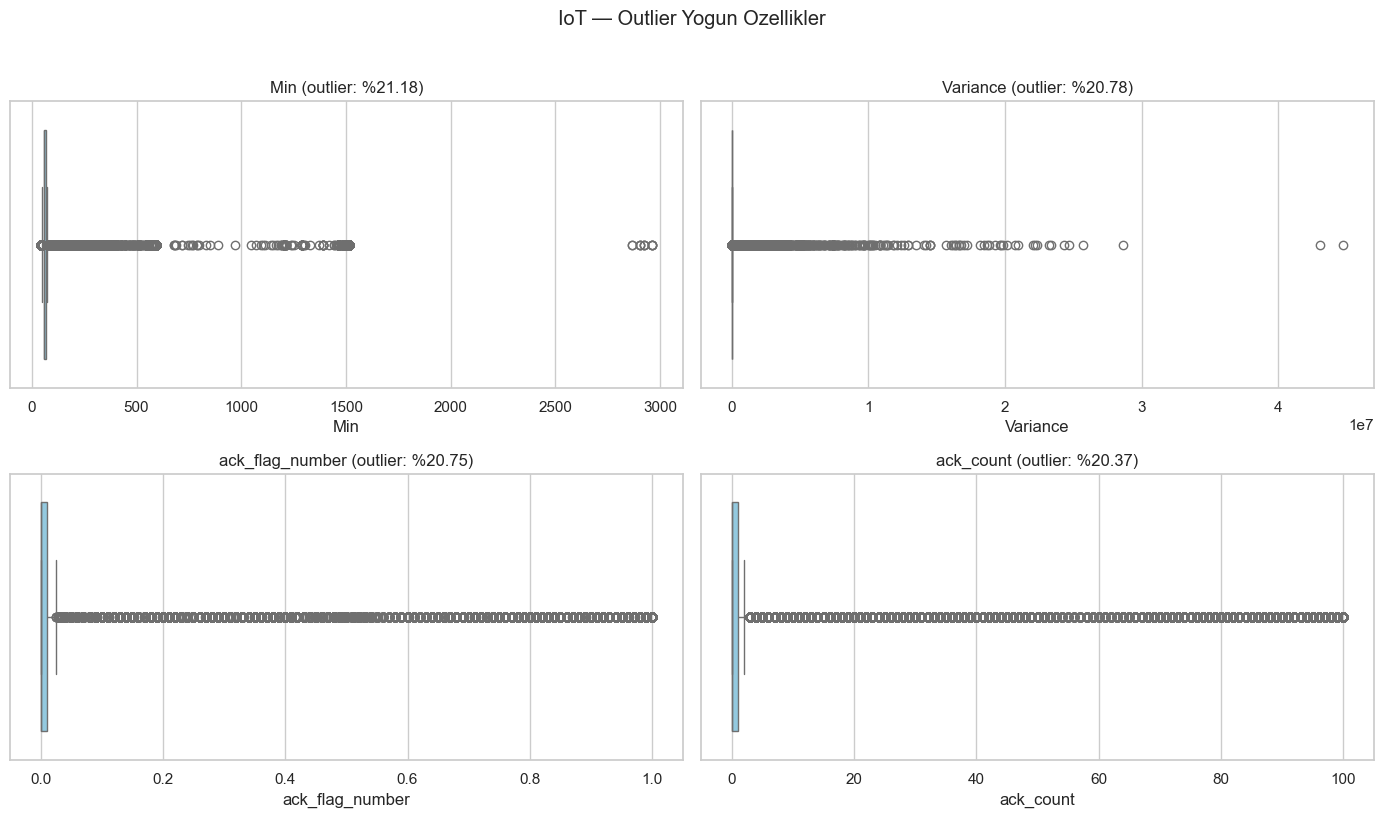

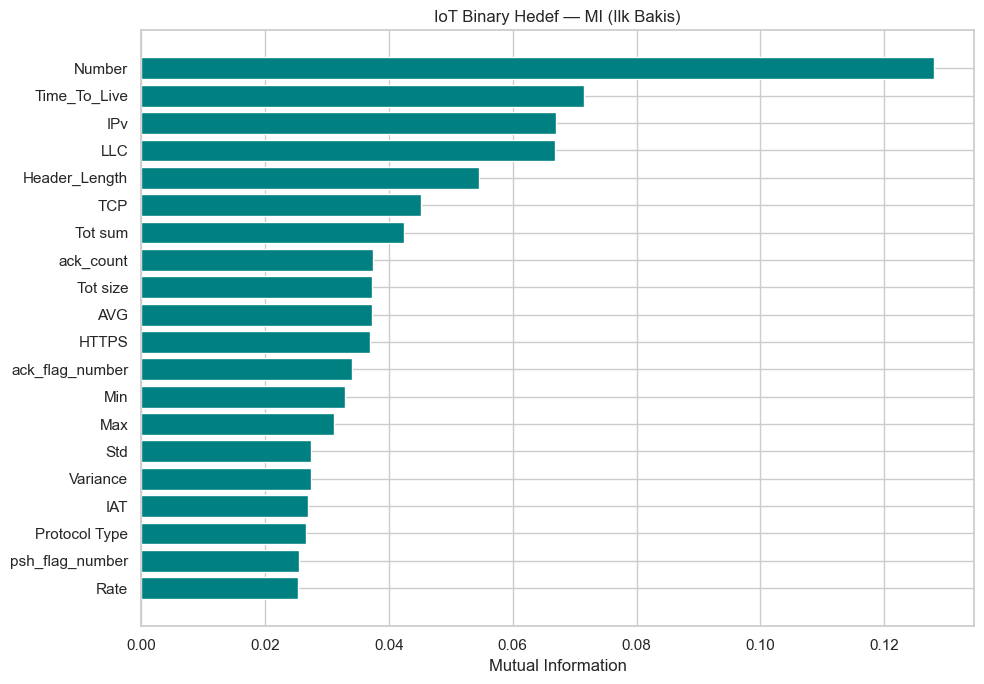

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

_root = None
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "configs" / "datasets.yaml").exists():
        _root = _candidate
        break
if _root is None:
    raise FileNotFoundError("Project root bulunamadi.")

_eda_dir = _root / "notebooks" / "eda"
for _path in (str(_root), str(_eda_dir)):
    if _path not in sys.path:
        sys.path.insert(0, _path)

from eda_common import find_project_root, run_iot_professional_eda

%matplotlib inline
run_iot_professional_eda(find_project_root(Path.cwd()))
plt.close("all")
